[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain（链）

## Review（回顾）

我们此前构建了一个简单的有向图：包含节点、普通边，以及“条件边（根据判断分支）”。

## Goals（目标）

现在我们把 4 个核心概念串成一条“链”（Chain）（参考文档链接）：

- 使用[聊天消息](https://python.langchain.com/v0.2/docs/concepts/#messages)作为图的状态（state）
- 在图的节点中使用[聊天模型](https://python.langchain.com/v0.2/docs/concepts/#chat-models)
- 将[工具](https://python.langchain.com/v0.2/docs/concepts/#tools)绑定到聊天模型
- 在图的节点中[执行工具调用](https://python.langchain.com/v0.2/docs/concepts/#functiontool-calling)

![链式结构示意图](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

## Messages（消息）

聊天模型使用[`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages)来承载对话上下文，其中每条消息都有“角色（role）”。

LangChain 支持多种消息类型：`HumanMessage`（用户）、`AIMessage`（模型/助手）、`SystemMessage`（系统指令）、`ToolMessage`（工具调用返回）。

它们分别表示：用户发言、模型回复、面向模型的系统指令、以及某个工具调用产生的消息。

下面我们来创建一个消息列表。

每条消息通常包含：

- `content`：消息内容（必填）
- `name`：消息作者（可选）
- `response_metadata`：响应元数据（可选，通常由模型提供方自动填充于 `AIMessage`）

In [ ]:
# 初学者提示：本示例演示如何构造“对话消息列表（messages）”，供聊天模型作为上下文输入。
# - HumanMessage 表示“人类（用户）”消息
# - AIMessage 表示“模型（助手）”消息
# - 每条消息可包含：content（内容）、name（可选的说话者名）、response_metadata（模型返回时的元数据）
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

# 我们用一个列表来按时间顺序保存对话历史。
messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
# 追加一条来自用户的消息
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
# 再追加一条来自模型的消息
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
# 用户继续追问
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

# 以更易读的格式打印每条消息，便于检查结构与顺序
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models（聊天模型）

[聊天模型](https://python.langchain.com/v0.2/docs/concepts/#chat-models)以“消息序列”作为输入，并支持上文提到的多种消息类型。

可选模型提供商有很多（见上方链接）。这里以 OpenAI 为例。

我们先检查环境变量 `OPENAI_API_KEY` 是否已设置；如果没有，将在 Notebook 中提示你安全输入。

In [ ]:
# 初学者提示：许多大模型 SDK 通过环境变量读取密钥（如 OPENAI_API_KEY）。
# 下面的辅助函数用于在未设置时，交互式地提示输入并写入当前进程环境变量。
# 注意：Notebook 会话结束后，需重新设置或在系统环境中长期配置。
import os, getpass

def _set_env(var: str):
    # 若系统环境中没有该变量，则通过安全输入进行设置
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置 OpenAI 的 API Key，供 ChatOpenAI 使用
_set_env("OPENAI_API_KEY")

我们可以加载一个聊天模型，并用我们的消息列表调用它。

你会看到返回的是一条 `AIMessage`，其中包含特定的 `response_metadata`（响应元数据）。

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [3]:
result

AIMessage(content='One of the best places to see orcas in the United States is the Pacific Northwest, particularly around the San Juan Islands in Washington State. Here are some details:\n\n1. **San Juan Islands, Washington**: These islands are a renowned spot for whale watching, with orcas frequently spotted between late spring and early fall. The waters around the San Juan Islands are home to both resident and transient orca pods, making it an excellent location for sightings.\n\n2. **Puget Sound, Washington**: This area, including places like Seattle and the surrounding waters, offers additional opportunities to see orcas, particularly the Southern Resident killer whale population.\n\n3. **Olympic National Park, Washington**: The coastal areas of the park provide a stunning backdrop for spotting orcas, especially during their migration periods.\n\nWhen planning a trip for whale watching, consider peak seasons for orca activity and book tours with reputable operators who adhere to re

In [4]:
result.response_metadata

{'token_usage': {'completion_tokens': 228,
  'prompt_tokens': 67,
  'total_tokens': 295,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_50cad350e4',
 'finish_reason': 'stop',
 'logprobs': None}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://python.langchain.com/v0.1/docs/integrations/chat/) and [tool calling interface](https://blog.langchain.dev/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

我们用一个极简示例演示工具调用。

这里把 `multiply` 函数当作我们的“工具”。

In [ ]:
# 初学者提示：把一个 Python 函数以“工具（tool）”的形式绑定给聊天模型。
# 作用：当任务需要结构化操作（如计算、查库、调 API），模型会优先生成工具调用参数并返回 tool_calls。
# 关键点：
# - 函数签名即是工具的“输入模式”，参数类型应明确；
# - 返回值需可序列化、简洁明确；
# - bind_tools([...]) 将工具元信息注册给模型。

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# 将 multiply 工具绑定到聊天模型实例
llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [8]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [9]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_lBBBNo5oYpHGRqwxNaNRbsiT',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [ ]:
# 定义图状态（State）：使用 TypedDict 定义键 messages
# 含义：messages 用于保存对话历史（列表），元素类型是 AnyMessage（可包含 Human/AI/Tool 等消息）
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers（归并器）

这里会遇到一个小问题：

按默认行为，每个节点返回的 `messages` 新值会[覆盖](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)旧值。

但在对话场景中，我们希望在运行过程中不断“追加”消息到 `messages`，而不是覆盖。

为此可以使用[归并器（reducer）](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)来定义“状态更新的合并规则”。

- 如果没有为某个键指定 reducer，则该键的更新将采用“覆盖”语义。
- 若要把消息追加到列表，应使用内置的 `add_messages` 归并器。

做法是：在状态类型中为 `messages` 键添加 `add_messages` 作为元数据注解，从而实现“追加而非覆盖”。

In [ ]:
# Reducer（归并器）：指定当节点返回新的 messages 时，如何与已有状态合并。
# add_messages 的语义是“追加消息而非覆盖”，保证完整的对话上下文得以保留。
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

将消息列表保存在图状态中非常常见，LangGraph 已内置 [`MessagesState`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)。

该类型具备以下特性：

- 预置一个 `messages` 键
- 值类型为 `list[AnyMessage]`
- 已默认使用 `add_messages` 归并器（自动追加）

因此通常直接使用内置的 `MessagesState`，比自定义 `TypedDict` 更简洁。

In [ ]:
# LangGraph 内置 MessagesState：已包含 messages 键与 add_messages 逻辑。
# 如需扩展，可继承后新增自定义键（如检索开关、工具开关、用户画像等）。
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

进一步了解：下面用一个最小示例单独演示 `add_messages` 归并器如何把新消息追加到已有列表中。

In [12]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', name='Model', id='cd566566-0f42-46a4-b374-fe4d4770ffa7'),
 HumanMessage(content="I'm looking for information on marine biology.", name='Lance', id='9b6c4ddb-9de3-4089-8d22-077f53e7e915'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', name='Model', id='74a549aa-8b8b-48d4-bdf1-12e98404e44e')]

## Our graph（我们的图）

下面用内置的 `MessagesState` 搭建一条最简单的“链式”对话图。

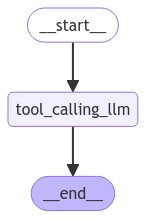

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# 节点函数：接收并返回“状态增量（partial state）”
# 入参 state：包含键 messages 的字典（对话历史）
# 返回：{"messages": [...]} —— 追加一条模型回复（可能包含工具调用）
# 注意：由于上文使用了 add_messages 作为 reducer，这里返回的列表会被“追加”到现有状态。
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"]) ]}

# 构建图
builder = StateGraph(MessagesState)
# 注册节点：名称 "tool_calling_llm" 对应上面的节点函数
builder.add_node("tool_calling_llm", tool_calling_llm)
# 拓扑：从 START 进入该节点，再从该节点到 END，形成一条“链”
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
# 编译图为可执行对象
graph = builder.compile()

# 可视化：通过 Mermaid 渲染图结构
display(Image(graph.get_graph().draw_mermaid_png()))

当输入 `Hello!` 这样的问候语时，模型会直接自然语言回复，不会触发任何工具调用。

In [ ]:
# 运行图（不涉及工具调用的普通对话）：
# 期望：模型直接以自然语言回复，不返回 tool_calls。
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hi there! How can I assist you today?


当模型判断用户输入/任务需要某个工具所提供的能力时，它会选择触发相应的工具调用。

In [ ]:
# 运行图（触发工具调用的请求）：
# 期望：模型返回带有 tool_calls 的 AIMessage，工具名与参数应符合 multiply(a, b)。
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_Er4gChFoSGzU7lsuaGzfSGTQ)
 Call ID: call_Er4gChFoSGzU7lsuaGzfSGTQ
  Args:
    a: 2
    b: 3
